# Phase 5: Market Behavior Engine - Visualization

This notebook visualizes the market trend effects from the Phase 5 Market Behavior Engine. It demonstrates:
- What drift and volatility mean, and how each behavior type adjusts them differently
- Simulated price paths compared across behaviors using a Monte Carlo ensemble (mean ± volatility band), so trend, volatility, and momentum differences are clearly distinguishable rather than subtle
- Multiple concurrent behaviors composed on one symbol at different, overlapping time windows

A single high base_volatility stock is used throughout so behavior effects are large enough to see clearly, and simulations span several trading days so drift differences have room to compound.

**Note:** All outputs are deterministic and reproducible using the same random seeds.


## Section 1: Setup Imports and Plotting Configuration

In [1]:
import sys
from datetime import datetime, timedelta
from decimal import Decimal
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pytz

# Add the project root to the path so we can import app modules
sys.path.insert(0, str(Path.cwd().parent))

from app.models import Stock
from app.simulation import (
    BehaviorType,
    MarketBehaviorConfig,
    MarketBehaviorEngine,
)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Timezone configuration
chicago_tz = pytz.timezone("America/Chicago")

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All imports successful")


✓ All imports successful


## Section 2: Define Shared Simulation Parameters

In [8]:
# Simulation parameters
# A high base_volatility stock is used everywhere in this notebook so behavior
# effects (especially Volatility Spike) are large enough to see clearly.
SYMBOL = "PNNY"
sim_stock = Stock(
    symbol=SYMBOL,
    company_name="Penny Growth Corp.",
    starting_price=Decimal("2.75"),
    sector="Speculative",
    average_volume=40_000_000,
    base_volatility=Decimal("0.85"),
)

BASE_DRIFT = 0.08
BASE_VOLATILITY = float(sim_stock.base_volatility)
INITIAL_PRICE = float(sim_stock.starting_price)

TRADING_HOURS_PER_DAY = 6.5
TRADING_DAYS_PER_YEAR = 252
SIMULATION_DAYS = 126  # ~6 months, long enough for annualized drift differences to visibly compound
STEP_INTERVAL = timedelta(minutes=1)
STEPS_PER_DAY = int(TRADING_HOURS_PER_DAY * 60)
NUM_STEPS = STEPS_PER_DAY * SIMULATION_DAYS

# Trading-year fraction represented by one simulation step
DT_YEARS = STEP_INTERVAL.total_seconds() / (TRADING_DAYS_PER_YEAR * TRADING_HOURS_PER_DAY * 3600)

# Start time (market hours in Chicago time)
START_TIME = chicago_tz.localize(datetime(2026, 8, 29, 8, 30, 0))

# Canonical timeline spanning several trading sessions back-to-back, plus its
# elapsed-trading-days equivalent (used as the x-axis for multi-day charts)
timeline = [START_TIME + (STEP_INTERVAL * (i + 1)) for i in range(NUM_STEPS)]
elapsed_trading_days = np.array([(i + 1) / STEPS_PER_DAY for i in range(NUM_STEPS)])

print("✓ Simulation parameters configured:")
print(f"  Symbol: {SYMBOL} (base_volatility={BASE_VOLATILITY:.0%})")
print(f"  Start: {START_TIME}")
print(f"  Duration: {SIMULATION_DAYS} trading days ({NUM_STEPS} steps)")
print(f"  Base Drift: {BASE_DRIFT:.2%}, Base Volatility: {BASE_VOLATILITY:.2%}")


✓ Simulation parameters configured:
  Symbol: PNNY (base_volatility=85%)
  Start: 2026-08-29 08:30:00-05:00
  Duration: 126 trading days (49140 steps)
  Base Drift: 8.00%, Base Volatility: 85.00%


## Section 3: Create Behavior Configurations for All BehaviorType Values

In [9]:
# Behavior configurations - one per type
# Duration spans the full multi-day simulation window at high strength, so
# drift/volatility differences have room to compound instead of looking subtle.
BEHAVIOR_DURATION = timedelta(hours=TRADING_HOURS_PER_DAY * SIMULATION_DAYS)
BEHAVIOR_STRENGTH = 0.9

behavior_configs = {
    behavior_type: MarketBehaviorConfig(
        symbol=SYMBOL,
        behavior_type=behavior_type,
        duration=BEHAVIOR_DURATION,
        strength=BEHAVIOR_STRENGTH,
    )
    for behavior_type in BehaviorType
}

# Create separate engines for each behavior type
behavior_engines = {
    name: MarketBehaviorEngine()
    for name in behavior_configs.keys()
}

# Add the behavior to its respective engine
for behavior_type, config in behavior_configs.items():
    engine = behavior_engines[behavior_type]
    engine.add_behavior_from_config(config, START_TIME)

print(f"✓ Created {len(behavior_configs)} behavior configurations:")
for behavior_type in behavior_configs.keys():
    print(f"  - {behavior_type}")
print(f"  Duration: {BEHAVIOR_DURATION}, Strength: {BEHAVIOR_STRENGTH}")


✓ Created 10 behavior configurations:
  - normal
  - uptrend
  - downtrend
  - sideways
  - momentum
  - mean_reversion
  - breakout
  - breakdown
  - consolidation
  - volatility_spike
  Duration: 34 days, 3:00:00, Strength: 0.9


## Section 4: Compute Time-Series Drift and Volatility Adjustments

**Drift** is the deterministic slope of the expected price path over time - it controls *direction* (up, down, or flat) and how fast the mean trend moves.

**Volatility** is the size of the random noise scattered around that trend - it controls *uncertainty* (how wide the range of possible outcomes is) without shifting the trend's direction.

A behavior can move either one independently: a trend behavior mostly shifts drift, a volatility behavior mostly widens/narrows the noise band, and momentum/mean-reversion behaviors move both together.


In [10]:
# Compute adjustments over time for each behavior
adjustment_records = []

for behavior_type, engine in behavior_engines.items():
    for step_index, timestamp in enumerate(timeline):
        adjusted_drift, adjusted_volatility = engine.get_adjustment(
            symbol=SYMBOL,
            base_drift=BASE_DRIFT,
            base_volatility=BASE_VOLATILITY,
            current_time=timestamp,
        )

        # Get active behaviors to track progress
        active_behaviors = engine.get_active_behaviors(SYMBOL, timestamp)
        progress = 0.0
        if active_behaviors:
            progress = active_behaviors[0].get_progress(timestamp)

        adjustment_records.append({
            'behavior': behavior_type,
            'timestamp': timestamp,
            'elapsed_days': elapsed_trading_days[step_index],
            'adjusted_drift': adjusted_drift,
            'adjusted_volatility': adjusted_volatility,
            'drift_change': adjusted_drift - BASE_DRIFT,
            'volatility_change': adjusted_volatility - BASE_VOLATILITY,
            'progress': progress,
        })

# Create DataFrame
adjustments_df = pd.DataFrame(adjustment_records)

print(f"✓ Computed {len(adjustments_df)} adjustment records")
print(f"  Behavior types: {adjustments_df['behavior'].nunique()}")
print(f"  Time range: {adjustments_df['timestamp'].min()} to {adjustments_df['timestamp'].max()}")
print("\nSample adjustments:")
print(adjustments_df.head(10))


✓ Computed 491400 adjustment records
  Behavior types: 10
  Time range: 2026-08-29 08:31:00-05:00 to 2026-10-02 11:30:00-05:00

Sample adjustments:
  behavior                 timestamp  elapsed_days  adjusted_drift  \
0   normal 2026-08-29 08:31:00-05:00      0.002564            0.08   
1   normal 2026-08-29 08:32:00-05:00      0.005128            0.08   
2   normal 2026-08-29 08:33:00-05:00      0.007692            0.08   
3   normal 2026-08-29 08:34:00-05:00      0.010256            0.08   
4   normal 2026-08-29 08:35:00-05:00      0.012821            0.08   
5   normal 2026-08-29 08:36:00-05:00      0.015385            0.08   
6   normal 2026-08-29 08:37:00-05:00      0.017949            0.08   
7   normal 2026-08-29 08:38:00-05:00      0.020513            0.08   
8   normal 2026-08-29 08:39:00-05:00      0.023077            0.08   
9   normal 2026-08-29 08:40:00-05:00      0.025641            0.08   

   adjusted_volatility  drift_change  volatility_change  progress  
0            

## Section 5: Visualize Drift and Volatility Curves by Behavior

Each behavior is active for the full simulation window at a constant strength, so its adjusted drift/volatility is a flat level rather than a ramp - this makes it easy to directly compare the *level* each behavior settles at, category by category.


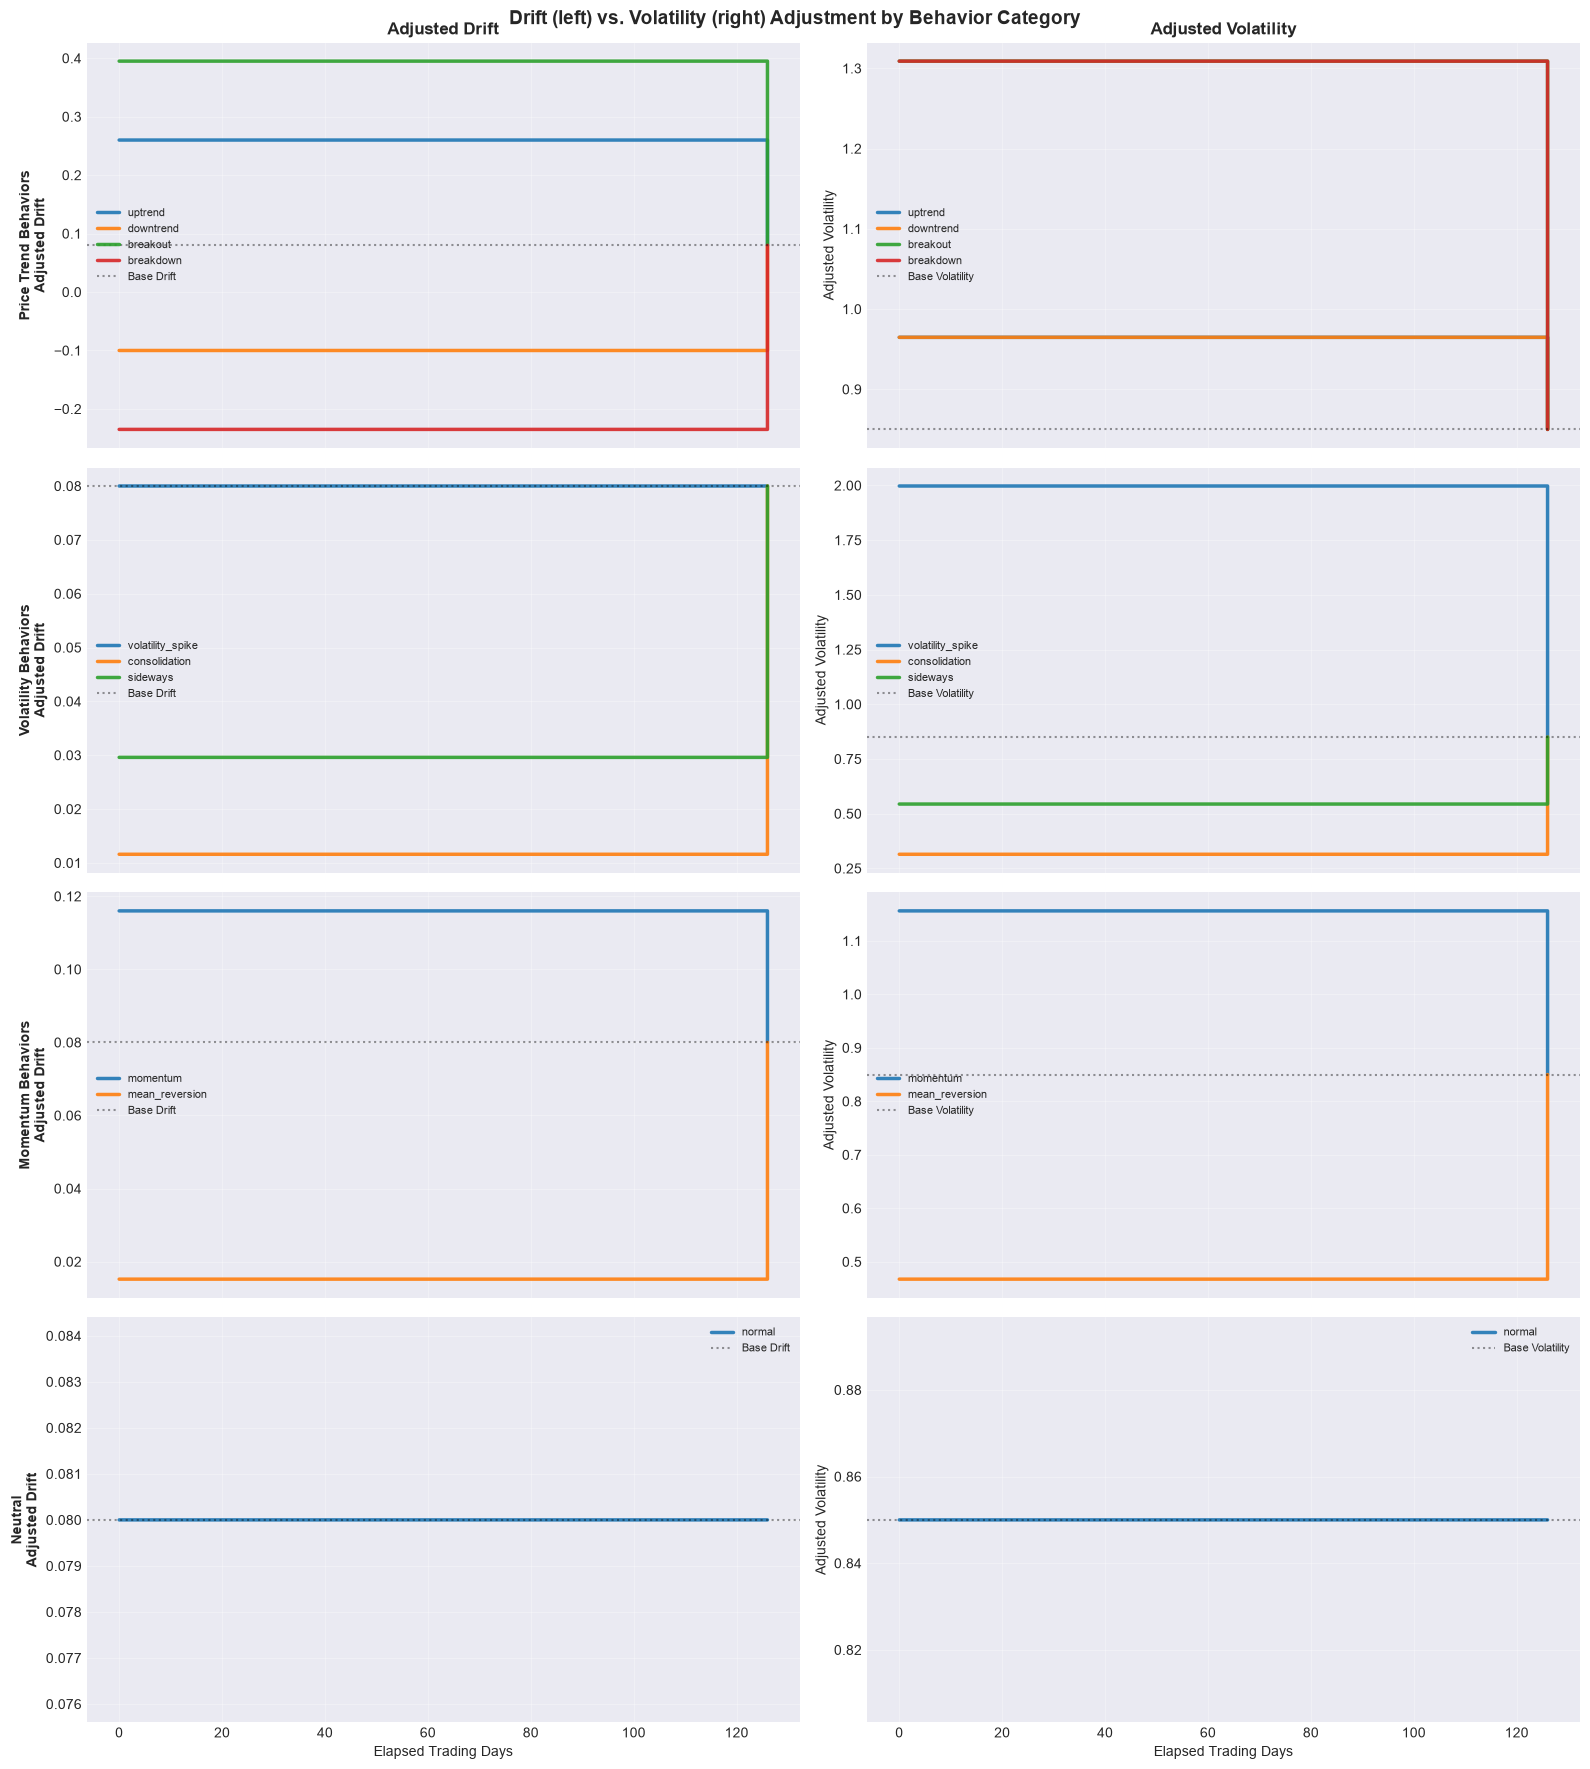

✓ Drift and volatility curves plotted


In [11]:
# Same category grouping is reused by every later section in this notebook
drift_price_movers = ['uptrend', 'downtrend', 'breakout', 'breakdown']
drift_volatility_behaviors = ['volatility_spike', 'consolidation', 'sideways']
drift_momentum_behaviors = ['momentum', 'mean_reversion']
drift_neutral = ['normal']

drift_categories = [
    ('Price Trend Behaviors', drift_price_movers),
    ('Volatility Behaviors', drift_volatility_behaviors),
    ('Momentum Behaviors', drift_momentum_behaviors),
    ('Neutral', drift_neutral),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 18), sharex=True)
fig.suptitle('Drift (left) vs. Volatility (right) Adjustment by Behavior Category', fontsize=14, fontweight='bold')

for row, (title, behaviors) in enumerate(drift_categories):
    drift_ax, vol_ax = axes[row, 0], axes[row, 1]

    for bname in behaviors:
        data = adjustments_df[adjustments_df['behavior'] == bname]
        drift_ax.plot(data['elapsed_days'], data['adjusted_drift'], label=bname, linewidth=2.5, alpha=0.9)
        vol_ax.plot(data['elapsed_days'], data['adjusted_volatility'], label=bname, linewidth=2.5, alpha=0.9)

    drift_ax.axhline(y=BASE_DRIFT, color='black', linestyle=':', alpha=0.4, label='Base Drift')
    vol_ax.axhline(y=BASE_VOLATILITY, color='black', linestyle=':', alpha=0.4, label='Base Volatility')

    drift_ax.set_ylabel(f'{title}\nAdjusted Drift', fontsize=10, fontweight='bold')
    vol_ax.set_ylabel('Adjusted Volatility', fontsize=10)
    drift_ax.legend(loc='best', fontsize=8)
    vol_ax.legend(loc='best', fontsize=8)
    drift_ax.grid(True, alpha=0.3)
    vol_ax.grid(True, alpha=0.3)

axes[0, 0].set_title('Adjusted Drift', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Adjusted Volatility', fontsize=12, fontweight='bold')

for ax in axes[-1, :]:
    ax.set_xlabel('Elapsed Trading Days')

plt.tight_layout()
plt.show()

print("✓ Drift and volatility curves plotted")


## Section 6: Understanding Drift vs. Volatility (Concept Plot)

For GBM, the arithmetic mean price is $E[S_t] = S_0 e^{\mu t}$ (depends only on drift $\mu$) and the variance is $\mathrm{Var}[S_t] = S_0^2 e^{2\mu t}(e^{\sigma^2 t} - 1)$ (depends only on volatility $\sigma$). Plotting these directly - with no random sampling - cleanly isolates exactly what each parameter controls: drift moves the line, volatility widens the band around it.


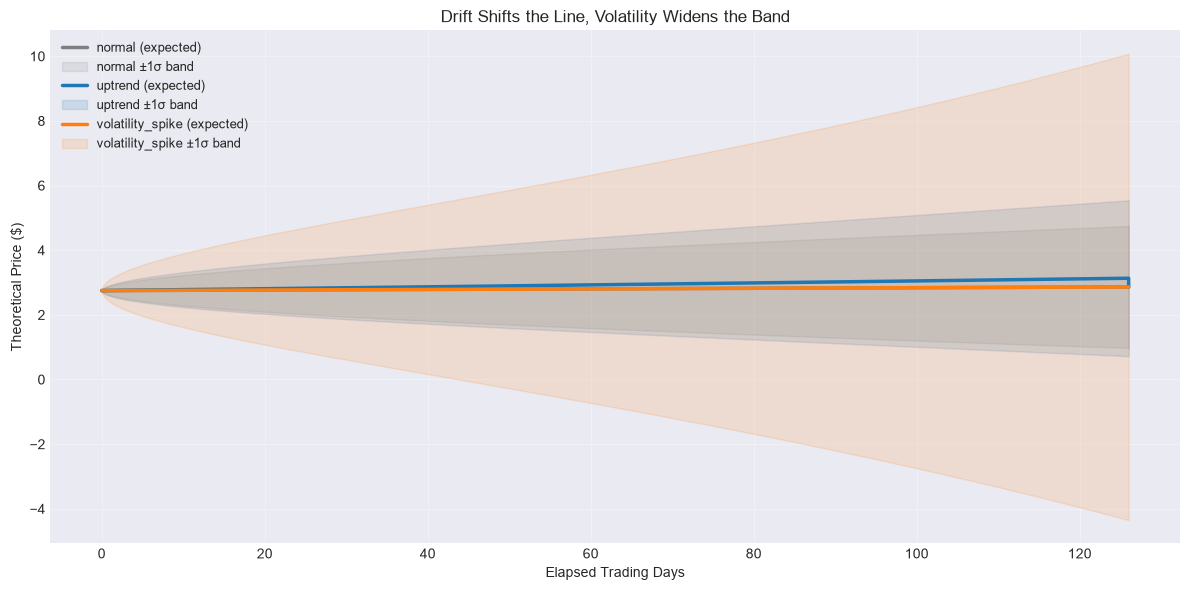

✓ Concept plot: Uptrend shifts the mean line; Volatility Spike widens the band without shifting it


In [12]:
concept_behaviors = ['normal', 'uptrend', 'volatility_spike']
concept_colors = {'normal': 'tab:gray', 'uptrend': 'tab:blue', 'volatility_spike': 'tab:orange'}

fig, ax = plt.subplots(figsize=(12, 6))

for bname in concept_behaviors:
    data = adjustments_df[adjustments_df['behavior'] == bname].sort_values('elapsed_days')
    mu = data['adjusted_drift'].to_numpy()
    sigma = data['adjusted_volatility'].to_numpy()
    t = data['elapsed_days'].to_numpy() / TRADING_DAYS_PER_YEAR

    # Arithmetic mean/variance of GBM: E[S_t]=S0*exp(mu*t) depends only on drift,
    # Var[S_t] depends only on volatility - this keeps the two effects fully separated
    expected_price = INITIAL_PRICE * np.exp(mu * t)
    variance = INITIAL_PRICE**2 * np.exp(2 * mu * t) * (np.exp(sigma**2 * t) - 1)
    std_price = np.sqrt(variance)
    upper = expected_price + std_price
    lower = expected_price - std_price

    color = concept_colors[bname]
    ax.plot(data['elapsed_days'], expected_price, label=f'{bname} (expected)', color=color, linewidth=2.5)
    ax.fill_between(data['elapsed_days'], lower, upper, color=color, alpha=0.15, label=f'{bname} \u00b11\u03c3 band')

ax.set_xlabel('Elapsed Trading Days')
ax.set_ylabel('Theoretical Price ($)')
ax.set_title('Drift Shifts the Line, Volatility Widens the Band')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Concept plot: Uptrend shifts the mean line; Volatility Spike widens the band without shifting it")


## Section 7: Compare Simulated Price Paths Across Behaviors (Ensemble Mean ± Volatility Band)

A single realized GBM path is dominated by random noise, so a subtle drift difference between behaviors can look invisible over a short window. Instead, we simulate a large ensemble of independent paths per behavior (using the *same* random shocks across behaviors, so only the behavior differs) and plot the mean cumulative return with a ±1σ band. This isolates the true drift-driven trend from noise and shows volatility as band width, so trend, volatility, and momentum differences are clearly distinguishable.


In [13]:
# Vectorized Monte Carlo ensemble: N_RUNS independent seeded paths per behavior
N_RUNS = 300
ensemble_rng = np.random.default_rng(123)

def simulate_ensemble(engine: MarketBehaviorEngine, shocks: np.ndarray) -> np.ndarray:
    """Return an (N_RUNS, NUM_STEPS) matrix of cumulative % returns for one behavior."""
    drifts = np.empty(NUM_STEPS)
    vols = np.empty(NUM_STEPS)
    for i, timestamp in enumerate(timeline):
        drifts[i], vols[i] = engine.get_adjustment(
            symbol=SYMBOL,
            base_drift=BASE_DRIFT,
            base_volatility=BASE_VOLATILITY,
            current_time=timestamp,
        )
    log_returns = (drifts - 0.5 * vols**2) * DT_YEARS + vols * np.sqrt(DT_YEARS) * shocks
    cumulative_log_returns = np.cumsum(log_returns, axis=1)
    return np.exp(cumulative_log_returns) - 1.0

# Same random shocks for every behavior so differences come only from drift/volatility, not luck
shared_shocks = ensemble_rng.standard_normal(size=(N_RUNS, NUM_STEPS))

ensemble_returns = {
    behavior_type: simulate_ensemble(engine, shared_shocks)
    for behavior_type, engine in behavior_engines.items()
}
mean_returns = {b: arr.mean(axis=0) for b, arr in ensemble_returns.items()}
std_returns = {b: arr.std(axis=0) for b, arr in ensemble_returns.items()}

print(f"✓ Simulated {N_RUNS} paths x {NUM_STEPS} steps for {len(ensemble_returns)} behaviors")


✓ Simulated 300 paths x 49140 steps for 10 behaviors


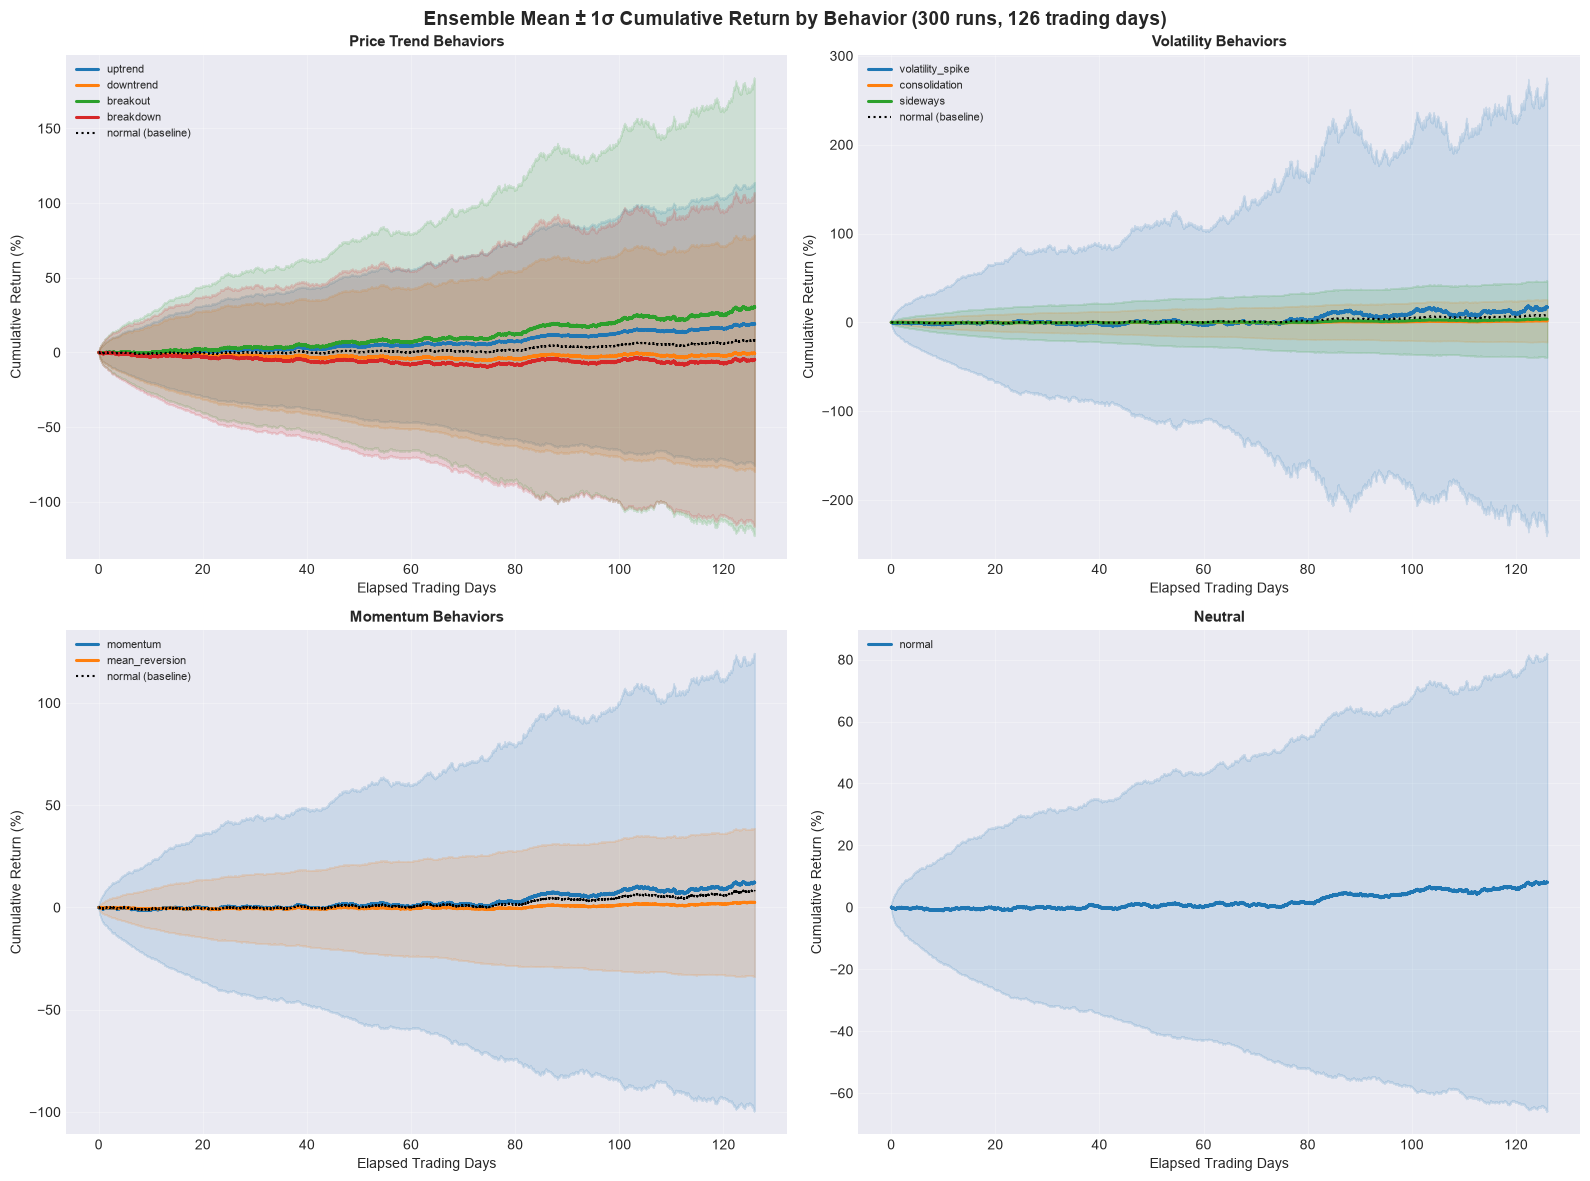

✓ Ensemble simulation summary after 126 trading days:

        Behavior Final Mean Return Final ±1σ Band
          normal              8.0%         ±73.8%
         uptrend             19.0%         ±94.4%
       downtrend             -0.6%         ±78.9%
        sideways              3.6%         ±43.1%
        momentum             12.2%        ±111.3%
  mean_reversion              2.5%         ±36.3%
        breakout             30.4%        ±152.2%
       breakdown             -4.9%        ±111.1%
   consolidation              1.6%         ±23.8%
volatility_spike             16.8%        ±252.7%


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f'Ensemble Mean \u00b1 1\u03c3 Cumulative Return by Behavior ({N_RUNS} runs, {SIMULATION_DAYS} trading days)',
    fontsize=14, fontweight='bold',
)

for (title, behaviors), ax in zip(drift_categories, axes.flat):
    for bname in behaviors:
        mean_pct = mean_returns[bname] * 100
        std_pct = std_returns[bname] * 100
        line, = ax.plot(elapsed_trading_days, mean_pct, label=bname, linewidth=2.2)
        ax.fill_between(elapsed_trading_days, mean_pct - std_pct, mean_pct + std_pct, alpha=0.15, color=line.get_color())

    if 'normal' not in behaviors:
        normal_pct = mean_returns['normal'] * 100
        ax.plot(elapsed_trading_days, normal_pct, label='normal (baseline)', color='black', linestyle=':', linewidth=1.5)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Elapsed Trading Days')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary metrics quantify how different the behaviors really are, not just "slightly different"
summary_rows = [
    {
        'Behavior': behavior_type,
        'Final Mean Return': f'{mean_returns[behavior_type][-1] * 100:.1f}%',
        'Final \u00b11\u03c3 Band': f'\u00b1{std_returns[behavior_type][-1] * 100:.1f}%',
    }
    for behavior_type in BehaviorType
]
summary_df = pd.DataFrame(summary_rows)

print(f"✓ Ensemble simulation summary after {SIMULATION_DAYS} trading days:\n")
print(summary_df.to_string(index=False))


## Section 8: Analyze Behavior Strength Sensitivity

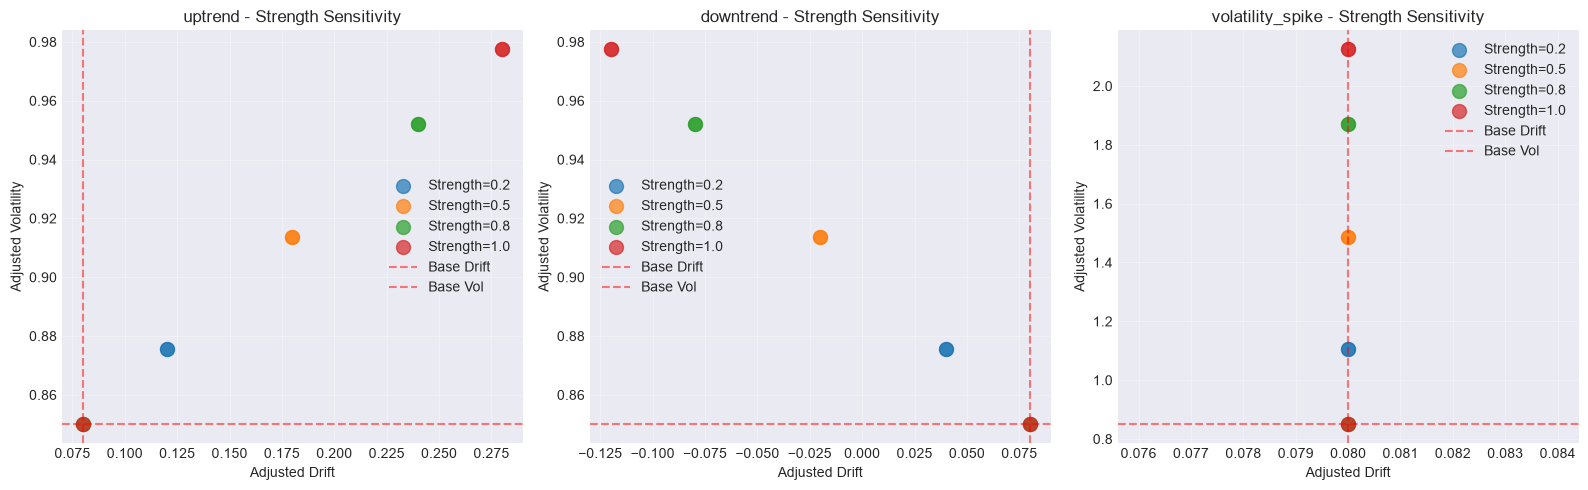

✓ Strength sensitivity analysis completed


In [15]:
# Strength sensitivity analysis for key behaviors
key_behaviors = [BehaviorType.UPTREND, BehaviorType.DOWNTREND, BehaviorType.VOLATILITY_SPIKE]
strengths = [0.2, 0.5, 0.8, 1.0]

sensitivity_records = []

for behavior_type in key_behaviors:
    for strength in strengths:
        # Create engine with specific strength
        engine = MarketBehaviorEngine()
        config = MarketBehaviorConfig(
            symbol=SYMBOL,
            behavior_type=behavior_type,
            duration=BEHAVIOR_DURATION,
            strength=strength,
        )
        engine.add_behavior_from_config(config, START_TIME)
        
        # Sample at start, middle, and end of behavior window
        sample_times = [
            START_TIME,
            START_TIME + BEHAVIOR_DURATION / 2,
            START_TIME + BEHAVIOR_DURATION,
        ]
        
        for sample_time in sample_times:
            adj_drift, adj_vol = engine.get_adjustment(
                symbol=SYMBOL,
                base_drift=BASE_DRIFT,
                base_volatility=BASE_VOLATILITY,
                current_time=sample_time,
            )
            
            sensitivity_records.append({
                'behavior': behavior_type,
                'strength': strength,
                'adjusted_drift': adj_drift,
                'adjusted_volatility': adj_vol,
            })

sensitivity_df = pd.DataFrame(sensitivity_records)

# Plot sensitivity
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, behavior in enumerate(key_behaviors):
    data = sensitivity_df[sensitivity_df['behavior'] == behavior]
    
    ax = axes[idx]
    for strength in strengths:
        strength_data = data[data['strength'] == strength]
        ax.scatter(strength_data['adjusted_drift'], strength_data['adjusted_volatility'], 
                  s=100, alpha=0.7, label=f'Strength={strength}')
    
    ax.axvline(x=BASE_DRIFT, color='red', linestyle='--', alpha=0.5, label='Base Drift')
    ax.axhline(y=BASE_VOLATILITY, color='red', linestyle='--', alpha=0.5, label='Base Vol')
    ax.set_xlabel('Adjusted Drift')
    ax.set_ylabel('Adjusted Volatility')
    ax.set_title(f'{behavior} - Strength Sensitivity')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Strength sensitivity analysis completed")

## Section 9: Demonstrate Multiple Concurrent Behaviors on One Symbol

Reuses the same shared stock/timeline and ensemble mean ± band technique from Section 7, applied to overlapping Uptrend and Volatility Spike windows so each behavior's effect - and their combination - is visible at the time it's actually active.


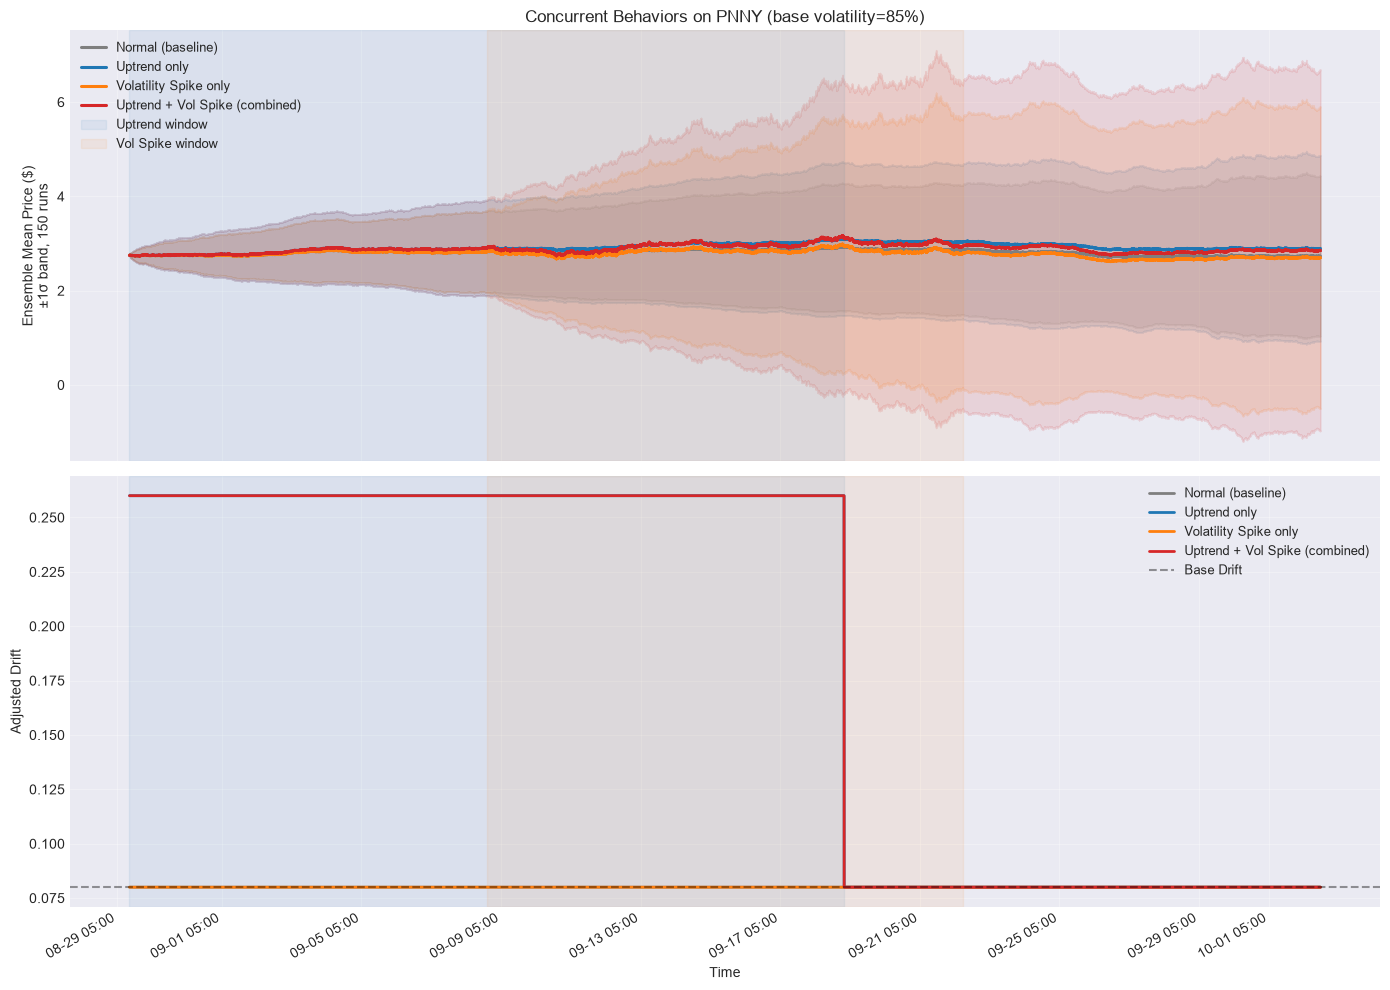

✓ Multiple concurrent behaviors demonstrated with ensemble mean ± band paths

Uptrend window: 08-29 08:30 - 09-18 19:54
Vol Spike window: 09-08 14:12 - 09-22 05:48
Overlap window: 09-08 14:12 - 09-18 19:54

Ending price by scenario (ensemble mean ± 1σ):
  Normal (baseline)                $2.73 ± 1.70
  Uptrend only                     $2.89 ± 1.97
  Volatility Spike only            $2.70 ± 3.19
  Uptrend + Vol Spike (combined)   $2.85 ± 3.82


In [16]:
# Offset, overlapping behavior windows within the shared multi-day timeline
total_duration = timedelta(hours=TRADING_HOURS_PER_DAY * SIMULATION_DAYS)
uptrend_start = START_TIME
uptrend_end = START_TIME + total_duration * 0.6
vol_start = START_TIME + total_duration * 0.3
vol_end = vol_start + total_duration * 0.4

uptrend_config = MarketBehaviorConfig(
    symbol=SYMBOL,
    behavior_type=BehaviorType.UPTREND,
    duration=uptrend_end - uptrend_start,
    strength=0.9,
)
volatility_config = MarketBehaviorConfig(
    symbol=SYMBOL,
    behavior_type=BehaviorType.VOLATILITY_SPIKE,
    duration=vol_end - vol_start,
    strength=0.9,
)

multi_engine = MarketBehaviorEngine()
multi_engine.add_behavior_from_config(uptrend_config, uptrend_start)
multi_engine.add_behavior_from_config(volatility_config, vol_start)

uptrend_only_engine = MarketBehaviorEngine()
uptrend_only_engine.add_behavior_from_config(uptrend_config, uptrend_start)

volatility_only_engine = MarketBehaviorEngine()
volatility_only_engine.add_behavior_from_config(volatility_config, vol_start)

normal_engine = MarketBehaviorEngine()

multi_scenarios = {
    'Normal (baseline)': normal_engine,
    'Uptrend only': uptrend_only_engine,
    'Volatility Spike only': volatility_only_engine,
    'Uptrend + Vol Spike (combined)': multi_engine,
}
multi_colors = {
    'Normal (baseline)': 'tab:gray',
    'Uptrend only': 'tab:blue',
    'Volatility Spike only': 'tab:orange',
    'Uptrend + Vol Spike (combined)': 'tab:red',
}

# Reuses simulate_ensemble() from Section 7; same shared stock/timeline, fewer runs for speed
N_RUNS_MULTI = 150
multi_rng = np.random.default_rng(7)
shared_shocks_multi = multi_rng.standard_normal(size=(N_RUNS_MULTI, NUM_STEPS))

multi_mean_price = {}
multi_std_price = {}
for label, engine in multi_scenarios.items():
    returns = simulate_ensemble(engine, shared_shocks_multi)
    multi_mean_price[label] = INITIAL_PRICE * (1 + returns.mean(axis=0))
    multi_std_price[label] = INITIAL_PRICE * returns.std(axis=0)

multi_adjustment_records = [
    {
        'label': label,
        'timestamp': ts,
        'adjusted_drift': engine.get_adjustment(
            symbol=SYMBOL, base_drift=BASE_DRIFT, base_volatility=BASE_VOLATILITY, current_time=ts,
        )[0],
    }
    for label, engine in multi_scenarios.items()
    for ts in timeline
]
multi_adjustments_df = pd.DataFrame(multi_adjustment_records)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for label in multi_scenarios:
    color = multi_colors[label]
    mean_p = multi_mean_price[label]
    std_p = multi_std_price[label]
    ax0.plot(timeline, mean_p, label=label, color=color, linewidth=2.2)
    ax0.fill_between(timeline, mean_p - std_p, mean_p + std_p, color=color, alpha=0.12)

ax0.axvspan(uptrend_start, uptrend_end, color='tab:blue', alpha=0.08, label='Uptrend window')
ax0.axvspan(vol_start, vol_end, color='tab:orange', alpha=0.08, label='Vol Spike window')
ax0.set_ylabel(f'Ensemble Mean Price ($)\n\u00b11\u03c3 band, {N_RUNS_MULTI} runs')
ax0.set_title(f'Concurrent Behaviors on {SYMBOL} (base volatility={BASE_VOLATILITY:.0%})')
ax0.legend(loc='best', fontsize=9)
ax0.grid(True, alpha=0.3)

for label in multi_scenarios:
    data = multi_adjustments_df[multi_adjustments_df['label'] == label]
    ax1.plot(data['timestamp'], data['adjusted_drift'], label=label, color=multi_colors[label], linewidth=2.0)

ax1.axhline(y=BASE_DRIFT, color='black', linestyle='--', alpha=0.4, label='Base Drift')
ax1.axvspan(uptrend_start, uptrend_end, color='tab:blue', alpha=0.08)
ax1.axvspan(vol_start, vol_end, color='tab:orange', alpha=0.08)
ax1.set_ylabel('Adjusted Drift')
ax1.set_xlabel('Time')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print("✓ Multiple concurrent behaviors demonstrated with ensemble mean \u00b1 band paths")
print(f"\nUptrend window: {uptrend_start.strftime('%m-%d %H:%M')} - {uptrend_end.strftime('%m-%d %H:%M')}")
print(f"Vol Spike window: {vol_start.strftime('%m-%d %H:%M')} - {vol_end.strftime('%m-%d %H:%M')}")
print(f"Overlap window: {vol_start.strftime('%m-%d %H:%M')} - {uptrend_end.strftime('%m-%d %H:%M')}")
print("\nEnding price by scenario (ensemble mean \u00b1 1\u03c3):")
for label in multi_scenarios:
    print(f"  {label:<32} ${multi_mean_price[label][-1]:.2f} \u00b1 {multi_std_price[label][-1]:.2f}")
